In [87]:
# Kmeans-> 스캐터, 실루엣점수, 센터찾기
# Scaling은 알아서 결정

## 군집화_정현용.ipynb

import pandas as pd
import numpy as np
import warnings

warnings.filterwarnings("ignore")

retail = pd.read_excel("../data/Online_Retail.xlsx", sheet_name = "Online Retail")

retail.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [109]:
df = retail.copy()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


In [89]:
# 전체 데이터 갯수: 541909
# object: InvoiceNo, StockCode, Description
# int: Quantity
# float: UnitPrice, CustomerID
# str: Country

In [110]:
# value_counts, null 찾기
# InvoiceNo

print(df["InvoiceNo"].value_counts()) # 한번에 주문한 물품갯수
print("--------------------------------------------")
print(df[df["InvoiceNo"] == 573585]["InvoiceDate"].value_counts())
print(df[df["InvoiceNo"] == 581219]["InvoiceDate"].value_counts())
# InvoiceNo가 같으면 한번에 다 주문한 것.

InvoiceNo
573585     1114
581219      749
581492      731
580729      721
558475      705
           ... 
581487        1
581491        1
C581499       1
581566        1
C581568       1
Name: count, Length: 25900, dtype: int64
--------------------------------------------
InvoiceDate
2011-10-31 14:41:00    1114
Name: count, dtype: int64
InvoiceDate
2011-12-08 09:28:00    749
Name: count, dtype: int64


In [111]:
# Stockcode

print(df["StockCode"].value_counts())

StockCode
85123A    2313
22423     2203
85099B    2159
47566     1727
20725     1639
          ... 
23609        1
85179a       1
23617        1
90214U       1
47591b       1
Name: count, Length: 4070, dtype: int64


In [112]:
# Description

df["Description"].value_counts()
df["Description"].isnull().sum() # 1454

# 결측치 어떤건지 보기위해 인덱스 찍기
index_list = df[df["Description"].isna()].index.tolist()
print(index_list)

# 결측치의 StockCode와 Description비교

# for index in index_list:
#     print(df.iloc[index])


[622, 1970, 1971, 1972, 1987, 1988, 2024, 2025, 2026, 2406, 4347, 4348, 7187, 7188, 7189, 7190, 7191, 7192, 7193, 7194, 7195, 7196, 7197, 7198, 7199, 7200, 7201, 7202, 7203, 7204, 7205, 7206, 7207, 7208, 7209, 7210, 7211, 7212, 7213, 7291, 7292, 7293, 12008, 12069, 12070, 12934, 13219, 13263, 13959, 13960, 13961, 13962, 14060, 14061, 14062, 14063, 14064, 14065, 14066, 14217, 17158, 19599, 19625, 19626, 19627, 19628, 19629, 19630, 19631, 19996, 19999, 20037, 20324, 20330, 20331, 20392, 20393, 20394, 20398, 20399, 20400, 20469, 20470, 20506, 20522, 21349, 21520, 21777, 21778, 21779, 21780, 21781, 21782, 21783, 21784, 21785, 21786, 21787, 21788, 21789, 21790, 21791, 21792, 21793, 22293, 22294, 22295, 22534, 23764, 23765, 23804, 25215, 25216, 29972, 30364, 31226, 34608, 38262, 38539, 38540, 38541, 38542, 39369, 40947, 42289, 42498, 42499, 42500, 42501, 42502, 42503, 42504, 42562, 42563, 42565, 42711, 43704, 44863, 45150, 45394, 45623, 46883, 50151, 50808, 51048, 51672, 51760, 51761, 51762,

In [ ]:
# CustomerID

df["CustomerID"].value_counts()
df["CustomerID"].isnull().sum() # 135080

# 회원정보 없는건 날리기 -> 고객식별 세그멘테이션이기 때문.

df = df[pd.notnull(df["CustomerID"])]

df.info()

<class 'pandas.DataFrame'>
Index: 406829 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    406829 non-null  object        
 1   StockCode    406829 non-null  object        
 2   Description  406829 non-null  object        
 3   Quantity     406829 non-null  int64         
 4   InvoiceDate  406829 non-null  datetime64[us]
 5   UnitPrice    406829 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      406829 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 27.9+ MB


In [ ]:
# Quantity 음수 제거
# UnitPric 0 제거

# print(df[df["Quantity"] < 0].value_counts().sum()) # 8905
# print(df[df["UnitPrice"] == 0].value_counts().sum()) # 40
# 8945개
# 406829 - 8945 = 397884

df = df[df["Quantity"] >= 0]
df = df[df["UnitPrice"] != 0]

df.info() # 397884

<class 'pandas.DataFrame'>
Index: 397884 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    397884 non-null  object        
 1   StockCode    397884 non-null  object        
 2   Description  397884 non-null  object        
 3   Quantity     397884 non-null  int64         
 4   InvoiceDate  397884 non-null  datetime64[us]
 5   UnitPrice    397884 non-null  float64       
 6   CustomerID   397884 non-null  float64       
 7   Country      397884 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 27.3+ MB


In [ ]:
# 필요없는값 삭제 후 데이터 null확인
df.isna().sum() # -> 0으로 확인 완료.

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

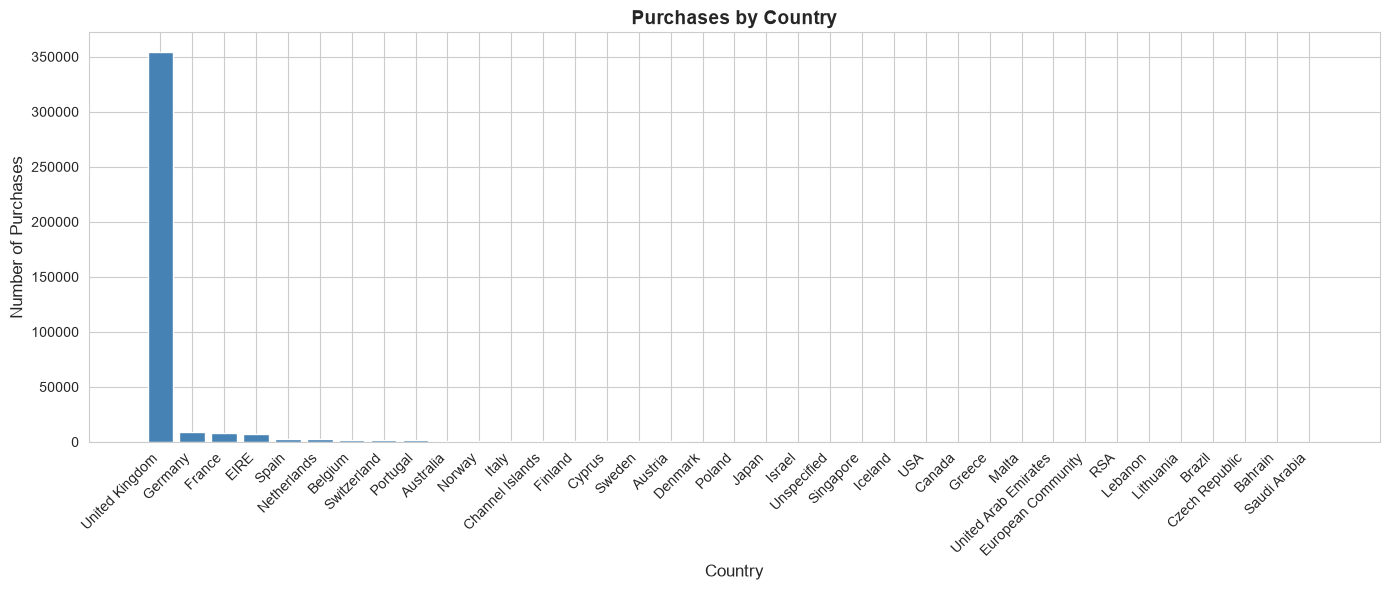

In [144]:
# 찾아본 결과 고객 세그멘테이션에서 UK(354,321건)외의 나라를 지우는거같은데..
# 제 생각엔 어쨌든 CustomerID를 통한 고객 분류이므로 굳이 UK가 거의 90%에 가까운 비율을 가지고있다고 다른 나라 데이터를 제거할 필요는 없을 것 같습니다.
# 따라서 CustomerID를 통해 분류를하고 혹시 다른 문제점이 생기면 그때가서 지우기 -> 미리 2가지 데이터 준비하기

# df["Country"].value_counts() -> UK혼자 35만건

import matplotlib.pyplot as plt
import seaborn as sns

purchases = df["Country"].value_counts()

plt.figure(figsize=(14, 6))
plt.bar(purchases.index, purchases.values, color='steelblue')
plt.xlabel('Country', fontsize=12)
plt.ylabel('Number of Purchases', fontsize=12)
plt.title('Purchases by Country', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Customer Segmentation

핵심 개념 -> RFM 피처
가장 널리 쓰이는 고객 분류 방법
- **Recency (R)**: 마지막 구매일로부터 오늘(기준일)까지 며칠 지났는가. 값이 작을수록 최근에 구매한 "활성" 고객.
- **Frequency (F)**: 얼마나 자주(몇 번) 구매했는가 = 고유 InvoiceNo(주문) 개수. 값이 클수록 충성도가 높은 고객.
- **Monetary (M)**: 총 얼마를 썼는가 = Σ(Quantity × UnitPrice). 값이 클수록 매출 기여도가 높은 고객.


In [201]:
df["TotalPrice"] = df["Quantity"] * df["UnitPrice"] # 각각의 총 가격을 구하기 위해 TotalPrice 컬럼 생성

snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1) # 기준일을 잡기위해 임의로 마지막 날짜 +1일로 설정
print("기준일:", snapshot_date)

rfm = df.groupby("CustomerID").agg(
    Recency=("InvoiceDate", lambda x: (snapshot_date - x.max()).days),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("TotalPrice", "sum")
).reset_index()
# 구매 고객에게 각각 고유의 CustomerID가 부여되기 때문에, CustomerID를 통해 groupby -> 총 4338명의 고객이 있음을 알 수 있다.
# 고객아이디는 정수로 변환해줌
rfm["CustomerID"] = rfm["CustomerID"].astype(int)

print(rfm.shape)
rfm.info()

기준일: 2011-12-10 12:50:00
(4338, 4)
<class 'pandas.DataFrame'>
RangeIndex: 4338 entries, 0 to 4337
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   CustomerID  4338 non-null   int64  
 1   Recency     4338 non-null   int64  
 2   Frequency   4338 non-null   int64  
 3   Monetary    4338 non-null   float64
dtypes: float64(1), int64(3)
memory usage: 135.7 KB


In [202]:
round(rfm[["Recency","Frequency","Monetary"]].describe(), 3)

,Recency,Frequency,Monetary
count,4338.000,4338.000,4338.000
mean,92.536,4.272,2054.266
std,100.014,7.698,8989.230
min,1.000,1.000,3.750
25%,18.000,1.000,307.415
50%,51.000,2.000,674.485
75%,142.000,5.000,1661.740
max,374.000,209.000,280206.020


Recency: 평균은 약 92.5일인데 반해, 중앙값은 51일 -> 오랫동안 구매를 하지 않은 고객들이 많다.
Frequency: 평균은 약 4.2회, 중앙값은 2회 -> 대부분 1,2회만 구매 후 구매를 하지않음, 최댓값 209번으로 매우 소수의 사람이 극단적으로 많이 구매하고있다는 뜻.
Monetary: 평균은 2054$(정확한 단위는 모르지만 우선 달러로 가정), 중앙값은 675$ -> 소수의 매우 큰 금액을 구매하는 사람들이 평균을 올리고 있음.

--> 히스토그램과 skew 그려보기.

왜도:
Recency       1.246
Frequency    12.067
Monetary     19.325
dtype: float64


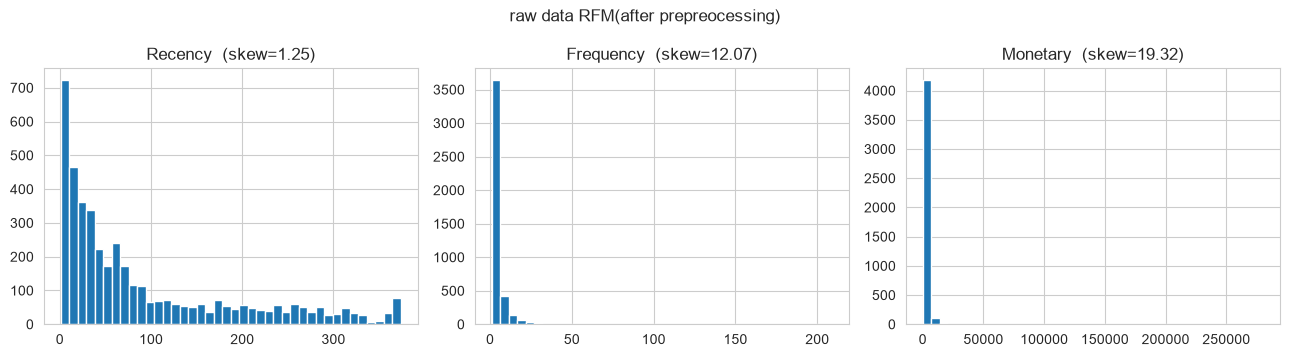

In [203]:
print("왜도:")
print(rfm[["Recency","Frequency","Monetary"]].skew().round(3))
# 왜도 1.25, 12.07, 19.32 특히 f,m에서 왜도가 심함.

import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
for ax, col in zip(axes, ["Recency","Frequency","Monetary"]):
    ax.hist(rfm[col], bins=40)
    ax.set_title(f"{col}  (skew={rfm[col].skew():.2f})")
fig.suptitle("raw data RFM(after prepreocessing)") # 데이터 정제 후 히스토그램
fig.tight_layout()
plt.show()

로그 변환 후 왜도:
Recency_log     -0.379
Frequency_log    1.209
Monetary_log     0.394
dtype: float64

스케일링 후 평균/표준편차 (모두 0, 1이어야 정상):
mean: [-0. -0.  0.]
std : [1. 1. 1.]


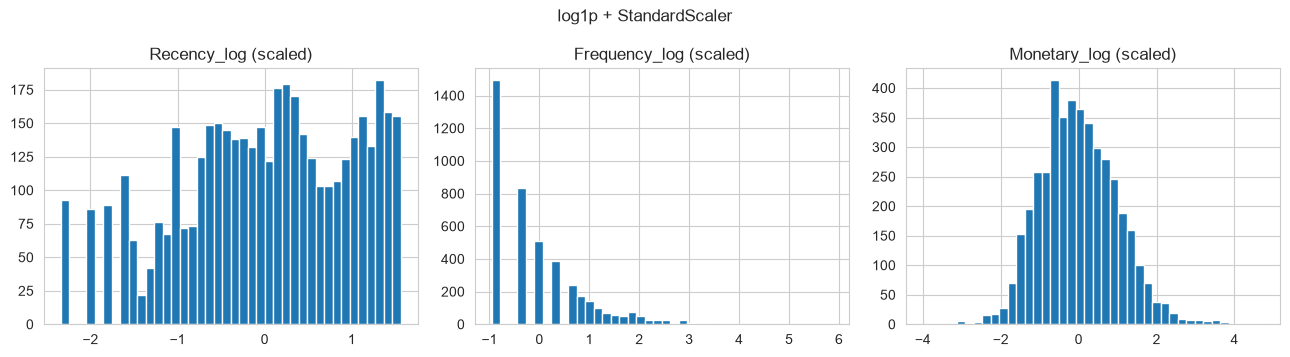

In [204]:
# 스케일링 전과 후 비교해보기.

from sklearn.preprocessing import StandardScaler

rfm_log = rfm.copy()
for col in ["Recency", "Frequency", "Monetary"]:
    rfm_log[col + "_log"] = np.log1p(rfm_log[col])

print("로그 변환 후 왜도:")
print(rfm_log[["Recency_log","Frequency_log","Monetary_log"]].skew().round(3))

X = rfm_log[["Recency_log","Frequency_log","Monetary_log"]].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\n스케일링 후 평균/표준편차 (모두 0, 1이어야 정상):")
print("mean:", np.round(X_scaled.mean(axis=0), 4))
print("std :", np.round(X_scaled.std(axis=0), 4))

fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
for ax, i, col in zip(axes, range(3), ["Recency_log","Frequency_log","Monetary_log"]):
    ax.hist(X_scaled[:, i], bins=40)
    ax.set_title(f"{col} (scaled)")
fig.suptitle("log1p + StandardScaler")
fig.tight_layout()
plt.show()

- 위의 그래프에 비해 훨씬 고르게 분포함을 알 수 있음.
- 특히 Monetray는 매우 좋은 효과를 보임.

- 왜도
* Recency: 1.247 -> -0.379
* Frequency: 12.067 -> 1.209
* Monetary: 19.325 -> 0.394

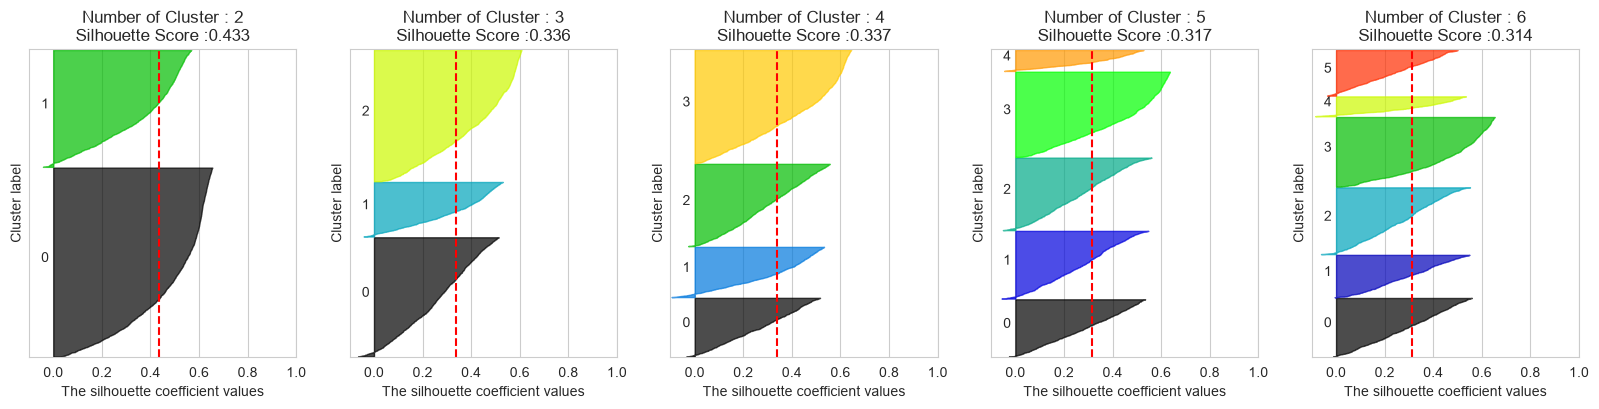

In [205]:
# 수업 시간의 실루엣 점수 함수를 통한 실루엣 점수 보기

def visualize_silhouette(cluster_lists, X_features): 
    
    from sklearn.datasets import make_blobs
    from sklearn.cluster import KMeans
    from sklearn.metrics import silhouette_samples, silhouette_score

    import matplotlib.pyplot as plt
    import matplotlib.cm as cm
    import math
    
    # 입력값으로 클러스터링 갯수들을 리스트로 받아서, 각 갯수별로 클러스터링을 적용하고 실루엣 개수를 구함
    n_cols = len(cluster_lists)
    
    # plt.subplots()으로 리스트에 기재된 클러스터링 수만큼의 sub figures를 가지는 axs 생성 
    fig, axs = plt.subplots(figsize=(4*n_cols, 4), nrows=1, ncols=n_cols)
    
    # 리스트에 기재된 클러스터링 갯수들을 차례로 iteration 수행하면서 실루엣 개수 시각화
    for ind, n_cluster in enumerate(cluster_lists):
        
        # KMeans 클러스터링 수행하고, 실루엣 스코어와 개별 데이터의 실루엣 값 계산. 
        clusterer = KMeans(n_clusters = n_cluster, max_iter=500, random_state=42)
        cluster_labels = clusterer.fit_predict(X_features)
        
        sil_avg = silhouette_score(X_features, cluster_labels)
        sil_values = silhouette_samples(X_features, cluster_labels)
        
        y_lower = 10
        axs[ind].set_title('Number of Cluster : '+ str(n_cluster)+'\n' \
                          'Silhouette Score :' + str(round(sil_avg,3)) )
        axs[ind].set_xlabel("The silhouette coefficient values")
        axs[ind].set_ylabel("Cluster label")
        axs[ind].set_xlim([-0.1, 1])
        axs[ind].set_ylim([0, len(X_features) + (n_cluster + 1) * 10])
        axs[ind].set_yticks([])  # Clear the yaxis labels / ticks
        axs[ind].set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1])
        
        # 클러스터링 갯수별로 fill_betweenx( )형태의 막대 그래프 표현. 
        for i in range(n_cluster):
            ith_cluster_sil_values = sil_values[cluster_labels==i]
            ith_cluster_sil_values.sort()
            
            size_cluster_i = ith_cluster_sil_values.shape[0]
            y_upper = y_lower + size_cluster_i
            
            color = cm.nipy_spectral(float(i) / n_cluster)
            axs[ind].fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_sil_values, \
                                facecolor=color, edgecolor=color, alpha=0.7)
            axs[ind].text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
            y_lower = y_upper + 10
            
        axs[ind].axvline(x=sil_avg, color="red", linestyle="--")

visualize_silhouette([2, 3, 4, 5, 6], X_scaled)

Silhouette 점수로는 3또는 4가 적합.

실루엣 점수 편차도 보기

In [206]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score

silhouette_df = pd.DataFrame(data = X_scaled, columns = ["log_Recency", "log_Frequency", "log_Monetary"])

kmeans = KMeans(n_clusters = 3, init = "k-means++", max_iter = 300, random_state = 42).fit(silhouette_df)

silhouette_df["cluster"] = kmeans.labels_

score_samples = silhouette_samples(X_scaled, silhouette_df['cluster'])
print(score_samples)

silhouette_df["silhouette_coeff"] = score_samples

avg_score = silhouette_score(X_scaled, silhouette_df["cluster"])
print(avg_score)

silhouette_df.head()

print(silhouette_df.groupby("cluster")["silhouette_coeff"].mean())

cluster_stats = silhouette_df.groupby('cluster')['silhouette_coeff'].agg(['mean', 'std', 'count'])
print("\n[군집별 실루엣 점수 요약]")
print(cluster_stats)
# 클러스터 3결과

[0.06799193 0.38481598 0.3953081  ... 0.14457686 0.4484616  0.4550391 ]
0.3360125435154917
cluster
0    0.259062
1    0.315529
2    0.414471
Name: silhouette_coeff, dtype: float64

[군집별 실루엣 점수 요약]
             mean       std  count
cluster                           
0        0.259062  0.146468   1696
1        0.315529  0.161850    776
2        0.414471  0.161733   1866


In [207]:
silhouette_df = pd.DataFrame(data = X_scaled, columns = ["log_Recency", "log_Frequency", "log_Monetary"])

kmeans = KMeans(n_clusters = 4, init = "k-means++", max_iter = 300, random_state = 42).fit(silhouette_df)

silhouette_df["cluster"] = kmeans.labels_

score_samples = silhouette_samples(X_scaled, silhouette_df['cluster'])
print(score_samples)

silhouette_df["silhouette_coeff"] = score_samples

avg_score = silhouette_score(X_scaled, silhouette_df["cluster"])
print(avg_score)

silhouette_df.head()

print(silhouette_df.groupby("cluster")["silhouette_coeff"].mean())

cluster_stats = silhouette_df.groupby('cluster')['silhouette_coeff'].agg(['mean', 'std', 'count'])
print("\n[군집별 실루엣 점수 요약]")
print(cluster_stats)

[0.17411326 0.4327245  0.55460625 ... 0.47859557 0.46842557 0.45524506]
0.3371343622222519
cluster
0    0.263444
1    0.305472
2    0.296762
3    0.418838
Name: silhouette_coeff, dtype: float64

[군집별 실루엣 점수 요약]
             mean       std  count
cluster                           
0        0.263444  0.150704    837
1        0.305472  0.172928    716
2        0.296762  0.151788   1173
3        0.418838  0.185761   1612


군집별 평균이 전체 평균과 유사하고, 표준편차 값이 작을수록 고르게 잘 분리된 군집이므로

클러스터 3 평균: 0.329687 / 표준편차: 0.156684
클러스터 4 평균: 0.321129 / 표준편차: 0.165295
-> 평균은 유사하나 편차가 3이 더 적으므로 3으로 결정.

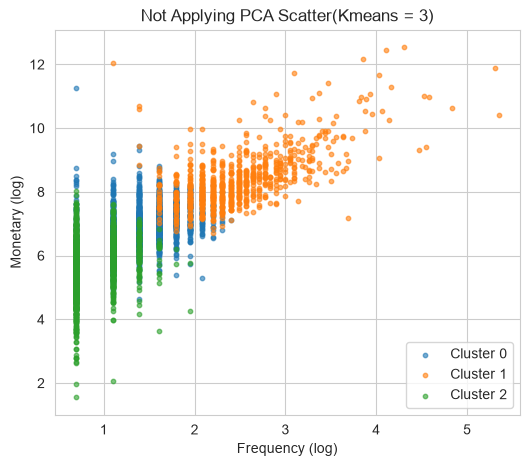

In [208]:
# PCA 미적용 clustering

kmeans = KMeans(n_clusters = 3, init = "k-means++", max_iter = 300, random_state = 42)

labels3 = kmeans.fit_predict(X_scaled)   # X_scaled: log1p + StandardScaler 적용된 (Recency, Frequency, Monetary)
rfm_log["Cluster3"] = labels3

plt.figure(figsize=(6, 5))
for ci in range(3):
    mask = rfm_log["Cluster3"] == ci
    plt.scatter(rfm_log.loc[mask, "Frequency_log"], rfm_log.loc[mask, "Monetary_log"],
                s=10, alpha=0.6, label=f"Cluster {ci}")
plt.xlabel("Frequency (log)")
plt.ylabel("Monetary (log)")
plt.title("Not Applying PCA Scatter(Kmeans = 3)")
plt.legend()
plt.show()

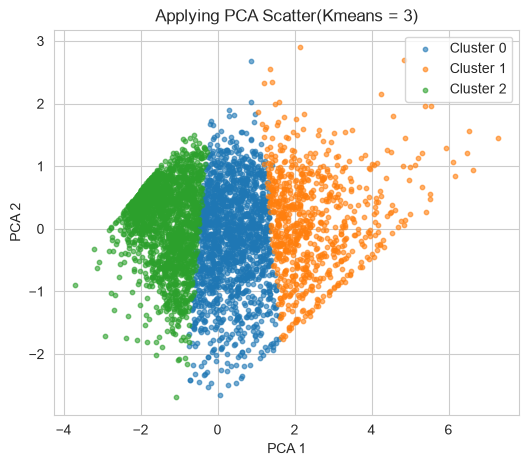

In [209]:
# PCA 적용

from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(6, 5))
for ci in range(3):
    mask = labels3 == ci
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], s=10, alpha=0.6, label=f"Cluster {ci}")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Applying PCA Scatter(Kmeans = 3)")
plt.legend()
plt.show()

**① PCA 축이 담고 있는 의미**

| 축 | 설명된 분산 | 구성 (로딩값) | 의미 |
|---|---|---|---|
| PC1 | 75.1% | -0.512×Recency + 0.618×Frequency + 0.597×Monetary | 최근·자주·많이 산 정도를 합친 "종합 고객가치 지수" (클수록 우량고객) |
| PC2 | 18.8% | 0.850×Recency + 0.262×Frequency + 0.457×Monetary | 거의 Recency 위주 — PC1이 못 담은 "최근성" 잔여 정보 |
| 합계 | 93.9% | — | 3개 피처 정보의 대부분을 2축에 보존 |

**② 군집별 RFM 프로필 (k=3)**

| PC1 위치 | Recency | Frequency | Monetary | 인원 | 세그먼트 |
|---|---|---|---|---|---|
| 오른쪽 끝 (최대) | 17.1일 | 13.3회 | $7,905 | 770명 | VIP (최근·잦음·고액) |
| 가운데 | 44.2일 | 3.4회 | $1,265 | 1,696명 | 일반 고객 |
| 왼쪽 (촘촘함) | 167.4일 | 1.4회 | $363 | 1,872명 | 휴면/이탈위험 |

-- 이부분은 제가 궁금해서 해본 내용입니다.--

**PCA 미적용 vs 적용 비교**

| 구분 | PCA 미적용 (Frequency vs Monetary) | PCA 적용 (PC1 vs PC2) |
|---|---|---|
| 군집 라벨 | 동일 (같은 KMeans 결과) | 동일 (같은 KMeans 결과) |
| 축의 정체 | 원래 피처 그대로 (사람이 임의로 2개 선택) | 3개 피처를 분산 기준으로 합성한 새 좌표 |
| 담긴 정보량 | 3개 중 2개만 (Recency 정보 누락) | 93.9% (거의 전부 보존) |
| 시각적 결과 | Recency 차이로 갈린 고객이 겹쳐 보일 수 있음 | 군집이 부채꼴로 뚜렷하게 분리 |
| 축의 해석 | $, 로그값 등 직접적 의미 있음 | PC1/PC2 자체는 추상적 합성값 |

**군집화 결과는 완전히 같지만, 차이는 "그 결과를 어떤 2차원 평면에 투영해서 보여주느냐"에서만 발생** (pca는 무조건 적용해야됨 하지않으면 정보를 다 담지 못함)

PCA 쪽이 정보 손실이 적어 군집 경계가 더 선명하게 보이는 것입니다. -> 3개의 칼럼 중 1개를 버려버려서 이상하게나옴. (제대로 구분을 못함 의미없음.)